In [15]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [16]:
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target
X.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [18]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))


Linear Regression MSE: 0.5558915986952442
Linear Regression R2: 0.575787706032451


In [19]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
print("Lasso Regression MSE:", mean_squared_error(y_test, y_pred_lasso))
print("Lasso Regression R2:", r2_score(y_test, y_pred_lasso))


Lasso Regression MSE: 0.6796290284328825
Lasso Regression R2: 0.48136113250290735


In [20]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
print("Ridge Regression MSE:", mean_squared_error(y_test, y_pred_ridge))
print("Ridge Regression R2:", r2_score(y_test, y_pred_ridge))


Ridge Regression MSE: 0.5558548589435971
Ridge Regression R2: 0.5758157428913684


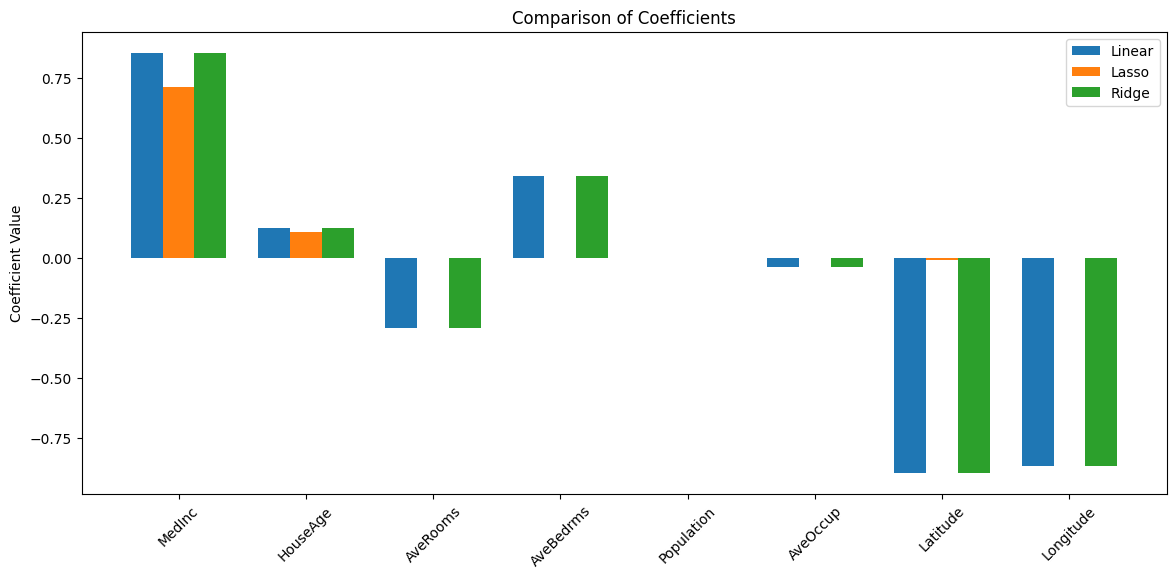

In [24]:
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Linear': lr.coef_,
    'Lasso': lasso.coef_,
    'Ridge': ridge.coef_
})

x = np.arange(len(X.columns))
width = 0.25

plt.figure(figsize=(14,6))
plt.bar(x - width, coef_df['Linear'], width, label='Linear')
plt.bar(x, coef_df['Lasso'], width, label='Lasso')
plt.bar(x + width, coef_df['Ridge'], width, label='Ridge')
plt.xticks(x, coef_df['Feature'], rotation=45)
plt.ylabel('Coefficient Value')
plt.title('Comparison of Coefficients')
plt.legend()
plt.show()
